**Verification of expressions used in the reference paper for the `Strauss2012` model.**

Reference paper: R. D. Strauss et al., Astrophys. Space Sci. (2012) 339:223-236

In [1]:
import sympy as sp

In [2]:
x, Omega, r, Vsw, alpha, phi, theta, beta = sp.symbols('x Omega r V_sw alpha phi theta beta', positive=True)

In [3]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'

In [4]:
theta_prime = sp.pi/2 + sp.asin(sp.sin(alpha) * sp.sin(phi+Omega*r/Vsw))                                                    

asin(sin(alpha)*sin(Omega*r/V_sw + phi)) + pi/2

In [5]:
theta_prime_simple = sp.pi/2 + alpha * sp.sin(phi+Omega*r/Vsw)

alpha*sin(Omega*r/V_sw + phi) + pi/2

In [6]:
sp.diff(sp.asin(x), x)

1/sqrt(1 - x**2)

In [7]:
sp.simplify(sp.asin(x)+sp.pi/2)

asin(x) + pi/2

In [8]:
tan2_beta = sp.simplify((-r*sp.diff(theta_prime, r))**2 + (1/sp.sin(theta) * sp.diff(theta_prime, phi))**2)

-(Omega**2*r**2 + V_sw**2/sin(theta)**2)*sin(alpha)**2*cos(Omega*r/V_sw + phi)**2/(V_sw**2*(sin(alpha)**2*sin(Omega*r/V_sw + phi)**2 - 1))

In [9]:
tan2_beta_simple = sp.simplify((-r*sp.diff(theta_prime_simple, r))**2 + (1/sp.sin(theta) * sp.diff(theta_prime_simple, phi))**2)

alpha**2*(Omega**2*r**2*sin(theta)**2 + V_sw**2)*cos(Omega*r/V_sw + phi)**2/(V_sw**2*sin(theta)**2)

In [10]:
sp.sin(x+sp.pi/2)

cos(x)

In [11]:
sp.sin(sp.atan(x))

x/sqrt(x**2 + 1)

In [12]:
sp.cos(sp.atan(x))

1/sqrt(x**2 + 1)

In [13]:
Psi = sp.atan(Omega*r/Vsw*sp.sin(theta))

atan(Omega*r*sin(theta)/V_sw)

In [14]:
expr = sp.simplify((Omega*r/Vsw/sp.sin(Psi))**2 * (sp.sin(alpha)**2-sp.cos(theta_prime)**2)/sp.sin(theta_prime)**2)

-(Omega**2*r**2 + V_sw**2/sin(theta)**2)*sin(alpha)**2*cos(Omega*r/V_sw + phi)**2/(V_sw**2*(sin(alpha)**2*sin(Omega*r/V_sw + phi)**2 - 1))

In [15]:
sp.simplify(tan2_beta-expr)

0

In [16]:
vns = 0.457 - 0.412*x + 0.0915*x**2

0.0915*x**2 - 0.412*x + 0.457

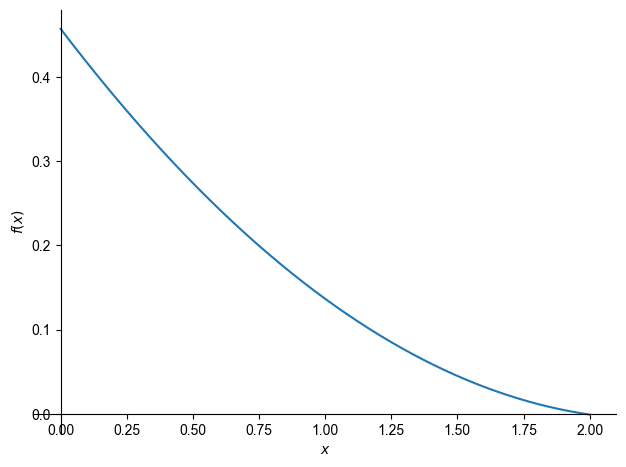

In [17]:
sp.plot(vns, (x, 0., 2.))

In [18]:
sp.cos(theta_prime)

-sin(alpha)*sin(Omega*r/V_sw + phi)

In [19]:
tan2_beta.subs([(r,0), (phi,0), (theta, sp.pi/2)])

sin(alpha)**2

In [22]:
rprime, phiprime = sp.symbols('rprime phiprime', positive=True)

In [23]:
theta_prime_simple.subs([(r, rprime), (phi, phiprime)])

alpha*sin(Omega*rprime/V_sw + phiprime) + pi/2

In [31]:
L2 = sp.simplify((r-rprime)**2 + r**2*(theta_prime_simple.subs([(r, rprime), (phi, phiprime)]) - theta)**2).subs(phiprime, phi)

r**2*(2*alpha*sin(Omega*rprime/V_sw + phi) - 2*theta + pi)**2/4 + (r - rprime)**2

In [41]:
L2.args[1].args[2].args[0]/2

alpha*sin(Omega*rprime/V_sw + phi) - theta + pi/2

In [32]:
dL2_drprime = sp.diff(L2, rprime)

Omega*alpha*r**2*(2*alpha*sin(Omega*rprime/V_sw + phi) - 2*theta + pi)*cos(Omega*rprime/V_sw + phi)/V_sw - 2*r + 2*rprime

In [33]:
sp.diff(dL2_drprime, rprime)

2*Omega**2*alpha**2*r**2*cos(Omega*rprime/V_sw + phi)**2/V_sw**2 - Omega**2*alpha*r**2*(2*alpha*sin(Omega*rprime/V_sw + phi) - 2*theta + pi)*sin(Omega*rprime/V_sw + phi)/V_sw**2 + 2